**Grupo 7:**

André Luiz Queiroz Valpassos

Luis Ernani Viniski

Lucas Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtendo os dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(file_path + '/temps.csv')

In [ ]:
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [ ]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


In [ ]:
df.drop(columns=["year", "month", "day", "week"], inplace=True)

In [ ]:
df.head()

,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,45,45,45.6,45,43,50,44,29
1,44,45,45.7,44,41,50,44,61
2,45,44,45.8,41,43,46,47,56
3,44,41,45.9,40,44,48,46,53
4,41,40,46.0,44,46,46,46,41


## Estatística Descritiva

<Axes: >

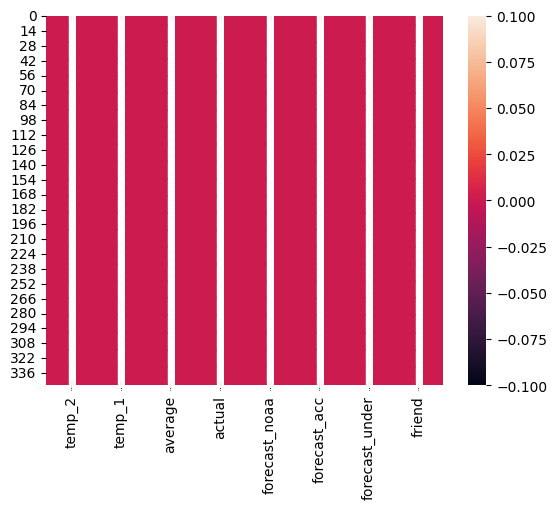

In [ ]:
sns.heatmap(df.isnull(), annot=True)

<Axes: >

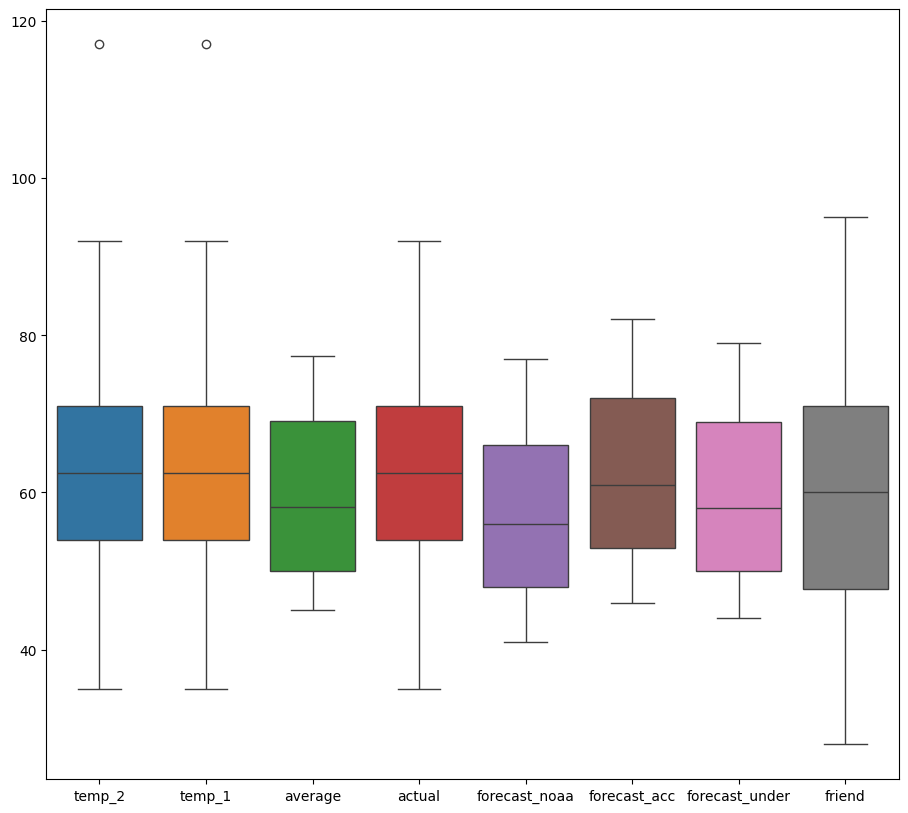

In [ ]:
plt.figure(figsize = (11, 10))
sns.boxplot(data=df)

<ipython-input-210-45d2cad639c0>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=True)


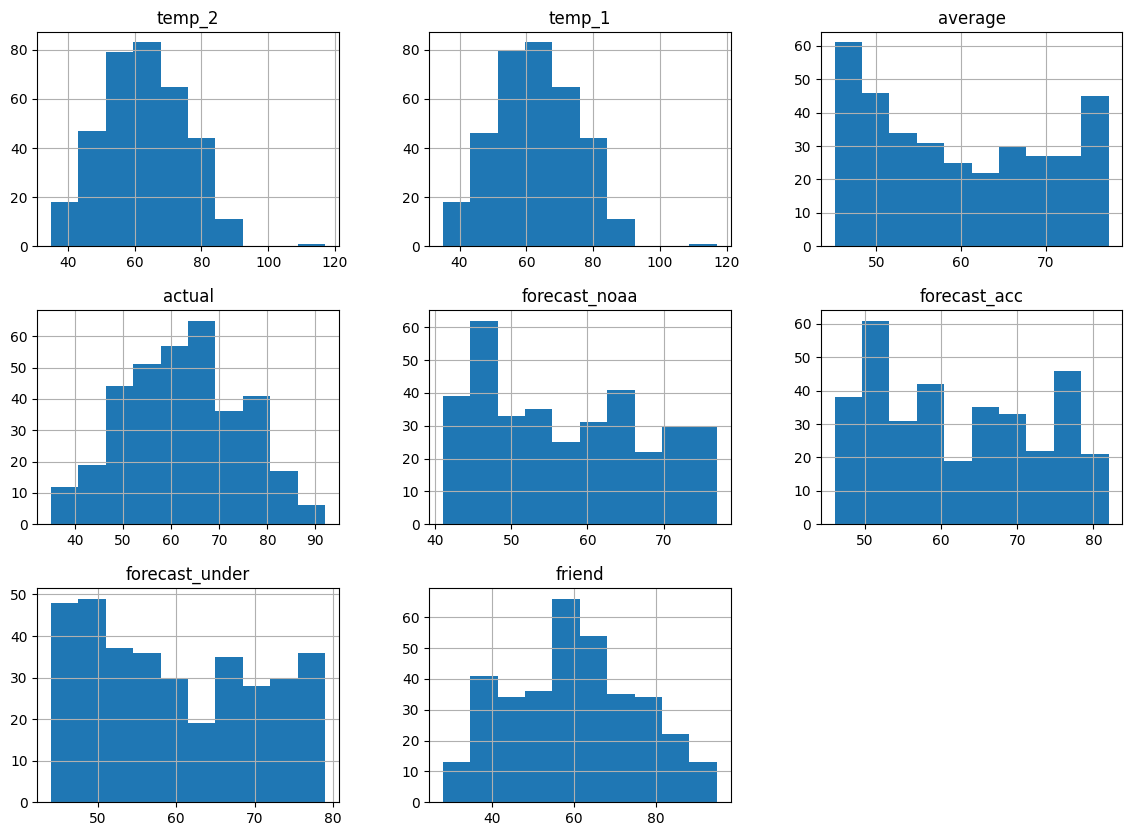

In [ ]:
fig = plt.figure(figsize = (14,10))
ax = fig.gca()
df.hist(ax = ax, grid=True)
plt.title("Dispersão dos dados")
plt.show()

<Axes: >

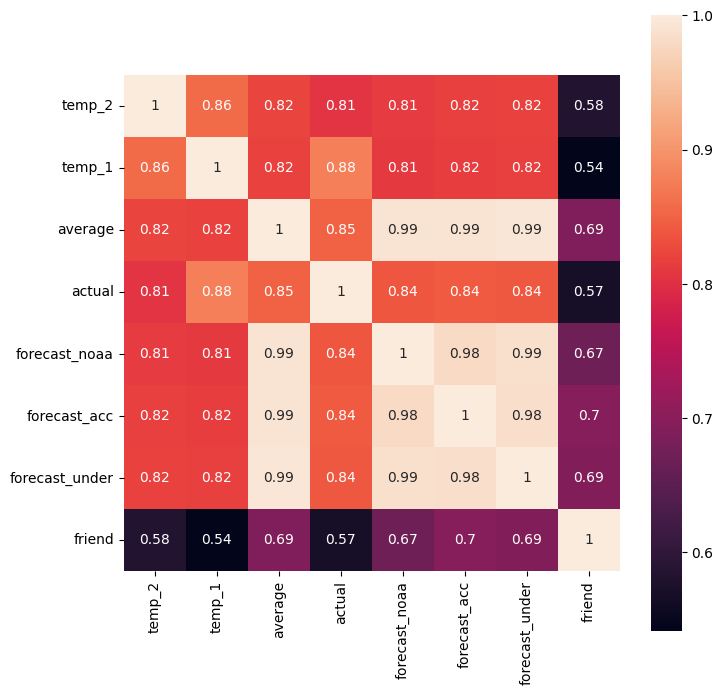

In [ ]:
plt.figure(figsize = (8, 8))
sns.heatmap(df.corr(),annot=True, square=True)

## Separação dos dados, holdout

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['actual']),
                                                    df['actual'],
                                                    test_size=0.25,
                                                    random_state=111)

In [ ]:
pd.DataFrame(X_train)

,temp_2,temp_1,average,forecast_noaa,forecast_acc,forecast_under,friend
120,77,87,62.1,62,66,64,69
20,48,52,47.8,43,51,46,57
114,59,60,60.7,59,65,60,50
264,63,64,62.5,60,65,61,73
239,70,74,71.5,71,75,70,82
...,...,...,...,...,...,...,...
169,70,76,70.8,68,75,71,57
275,60,61,58.4,58,60,57,41
86,56,64,55.7,51,57,56,57
212,77,73,77.3,77,81,77,93


## Normalização dos dados

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled[:3]

array([[ 1.17318321,  1.97519864,  0.17908574,  0.40319769,  0.31190317,
         0.35302158,  0.50816738],
       [-1.30444617, -0.92660895, -1.19312058, -1.40462993, -1.1366151 ,
        -1.33932067, -0.26821322],
       [-0.36465572, -0.26333864,  0.04474386,  0.11775122,  0.21533528,
        -0.02305447, -0.72110191]])

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261 entries, 120 to 340
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp_2          261 non-null    float64
 1   temp_1          261 non-null    float64
 2   average         261 non-null    float64
 3   forecast_noaa   261 non-null    float64
 4   forecast_acc    261 non-null    float64
 5   forecast_under  261 non-null    float64
 6   friend          261 non-null    float64
dtypes: float64(7)
memory usage: 16.3 KB


In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_test_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 49 to 244
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp_2          87 non-null     float64
 1   temp_1          87 non-null     float64
 2   average         87 non-null     float64
 3   forecast_noaa   87 non-null     float64
 4   forecast_acc    87 non-null     float64
 5   forecast_under  87 non-null     float64
 6   friend          87 non-null     float64
dtypes: float64(7)
memory usage: 5.4 KB


## Árvores de Decisão

In [ ]:
from sklearn import tree

In [ ]:
model = tree.DecisionTreeRegressor()

In [ ]:
model.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

### Executar o modelo treinado na base de treinamento

In [ ]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [ ]:
model.score(X_train_scaled, y_train)

1.0

In [ ]:
model.score(X_test_scaled, y_test)

0.6318705354523096

### Avaliação de Regressores - Exibir os Resultados

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [ ]:
def print_metrics(y_test, y_test_pred):
  print("MEAN: ", mean_absolute_error(y_test, y_test_pred))
  print("MAPE: ", mean_absolute_percentage_error(y_test, y_test_pred))
  print("MSE: ", mean_squared_error(y_test, y_test_pred))
  print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
  print("R²: ", r2_score(y_test, y_test_pred))

In [ ]:
print_metrics(y_test, y_test_pred)

MEAN:  5.597701149425287
MAPE:  0.08948321087894542
MSE:  54.701149425287355
RMSE:  7.396022540885564
R²:  0.6318705354523096


## Validação cruzada com o algoritmo Árvores de Decisão

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
y = df['actual']
X = df.drop(columns=['actual'])
reg_cv_scores = cross_validate(model, X_test_scaled, y_test_pred, cv=5, scoring='r2')

In [ ]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (reg_cv_scores['test_score'].mean(), reg_cv_scores['test_score'].std()))

0.75 accuracy with a standard deviation of 0.06


### Exibindo a árvore de decisão do modelo treinado

In [ ]:
from sklearn import tree

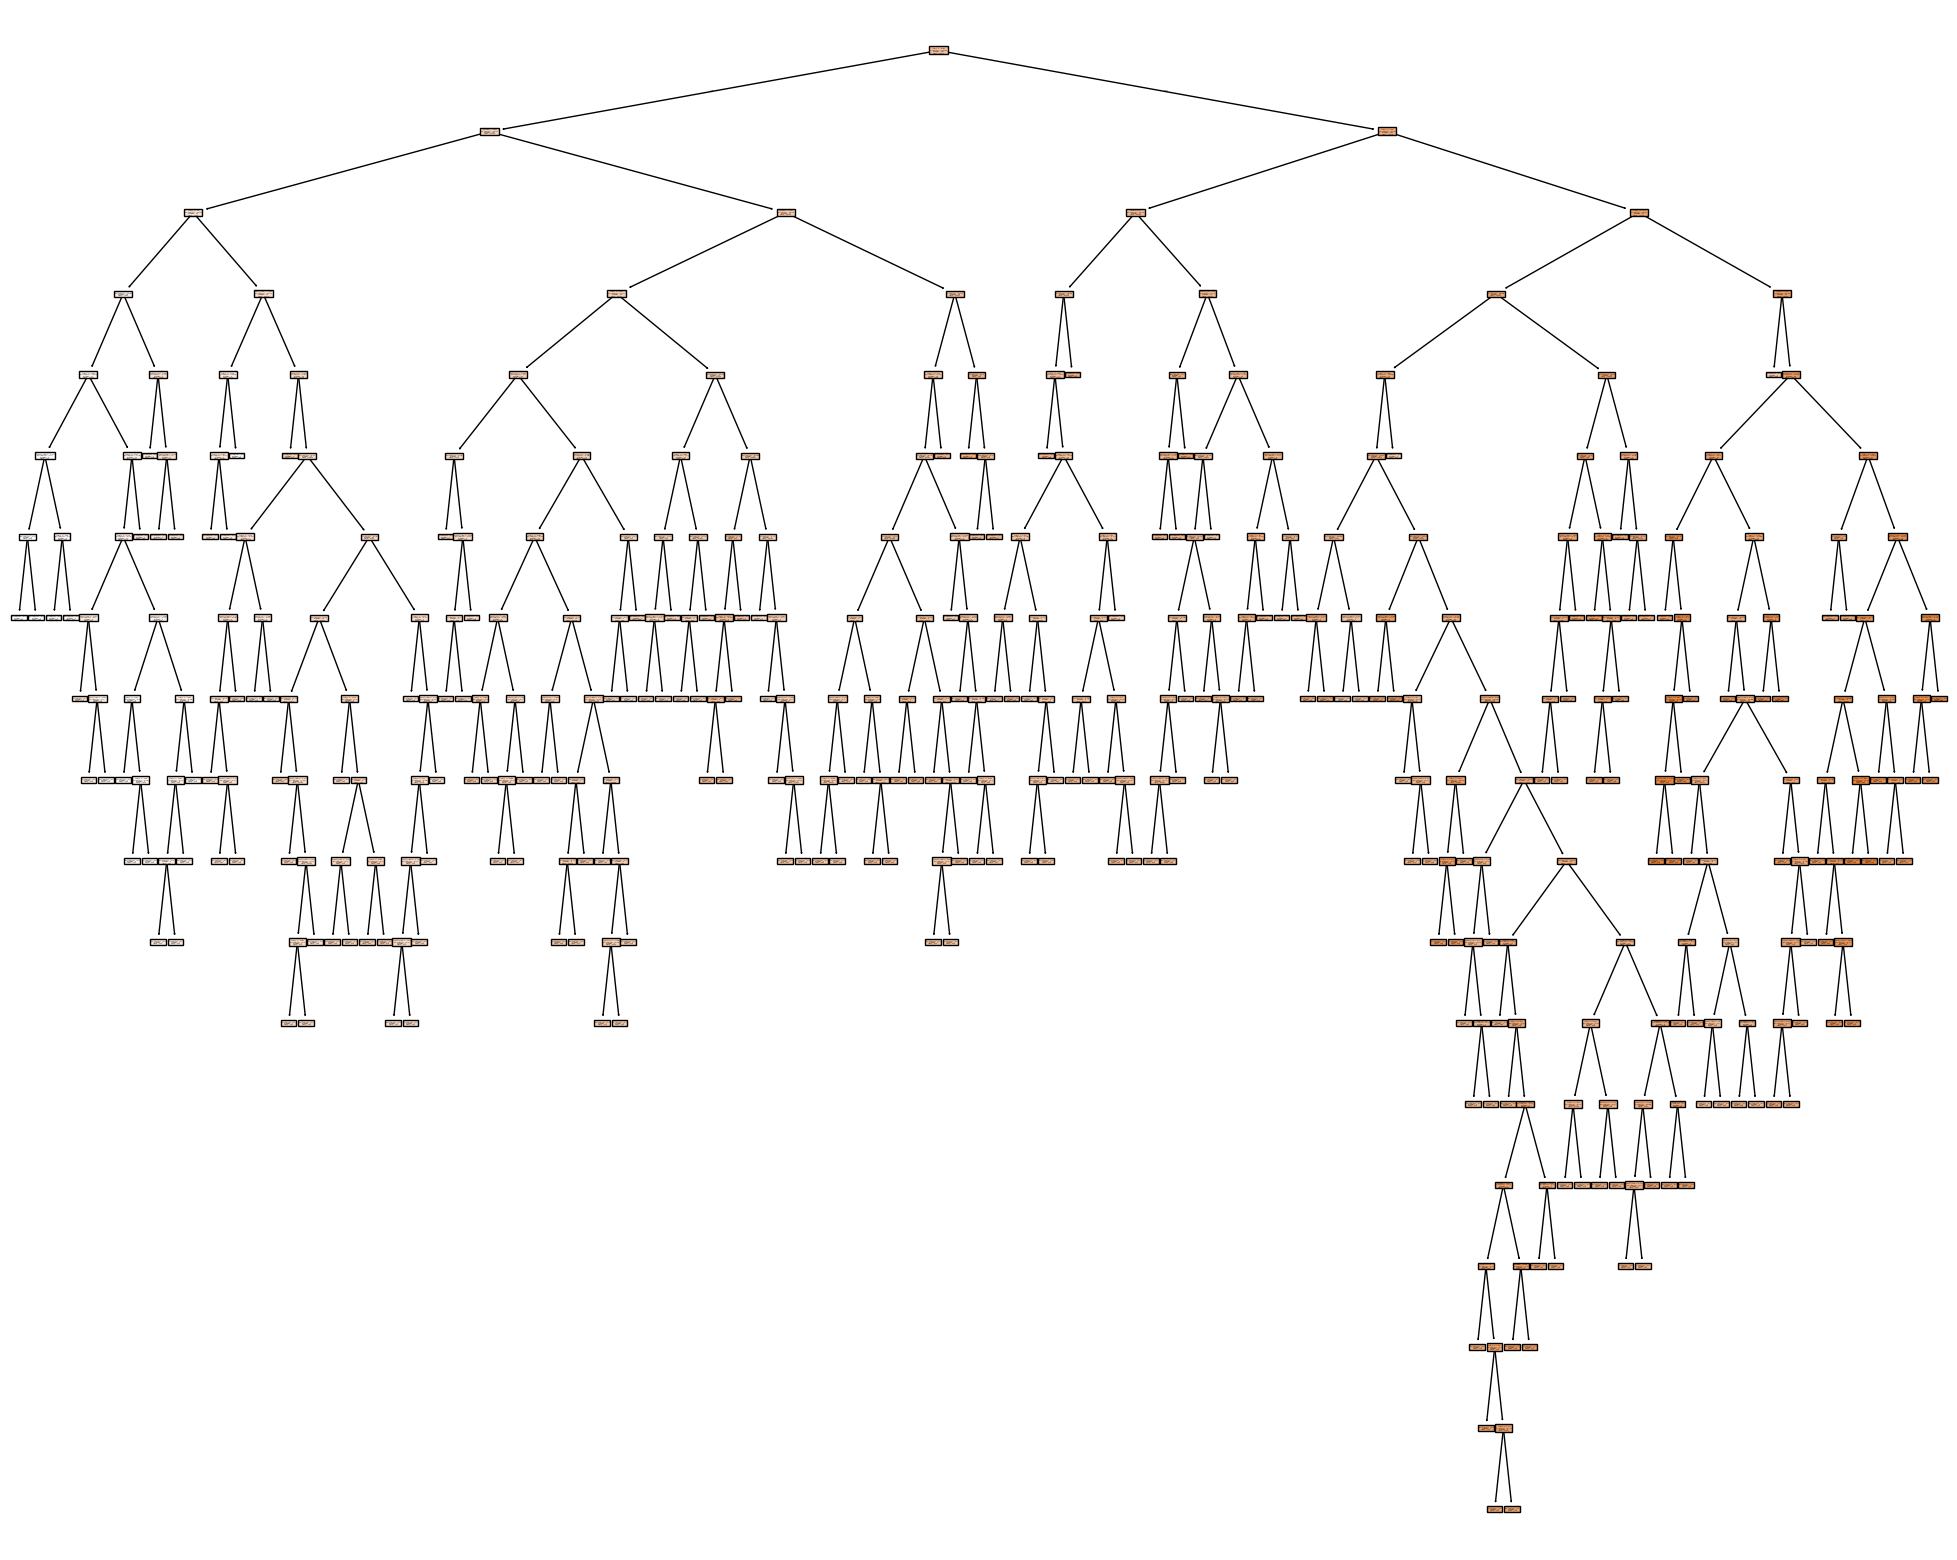

In [ ]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(model,
                   feature_names=X_train.columns,
                   class_names=y_test.unique(),
                   filled=True)

### Avaliar o melhor valor de max_depth

Text(0, 0.5, 'Score Rate')

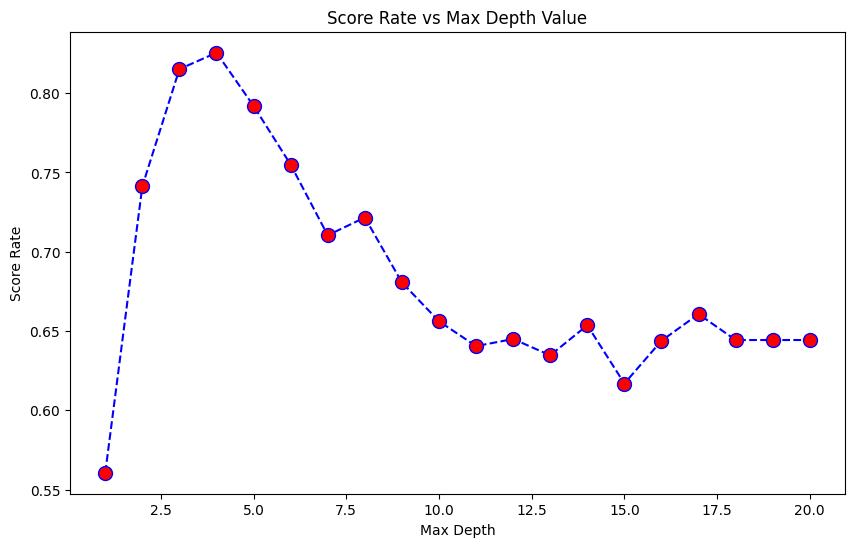

In [ ]:
import numpy as np

score = []

for i in range(1,21):
  model = tree.DecisionTreeRegressor(max_depth=i, random_state=42)
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  r2 = r2_score(y_test, y_pred)
  score.append(r2)

plt.figure(figsize=(10,6))
plt.plot(range(1,21), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score Rate vs Max Depth Value')
plt.xlabel('Max Depth')
plt.ylabel('Score Rate')

### Criando um regressor com o melhor valor para max_depth e avaliando

In [ ]:
reg_best = tree.DecisionTreeRegressor(max_depth=score.index(max(score))+1)

reg_best.fit(X_train, y_train)
print('Train: ', reg_best.score(X_train, y_train))
print('Test: ',reg_best.score(X_test, y_test))

Train:  0.8770739780380298
Test:  0.825453102653524


In [ ]:
print_metrics(y_test, reg_best.predict(X_test))

MEAN:  4.134991467851509
MAPE:  0.06786982417186785
MSE:  25.936299136503827
RMSE:  5.092769299360008
R²:  0.825453102653524


### Plot dos valores previstos vs reais

In [ ]:
y_pred = reg_best.predict(X_test)

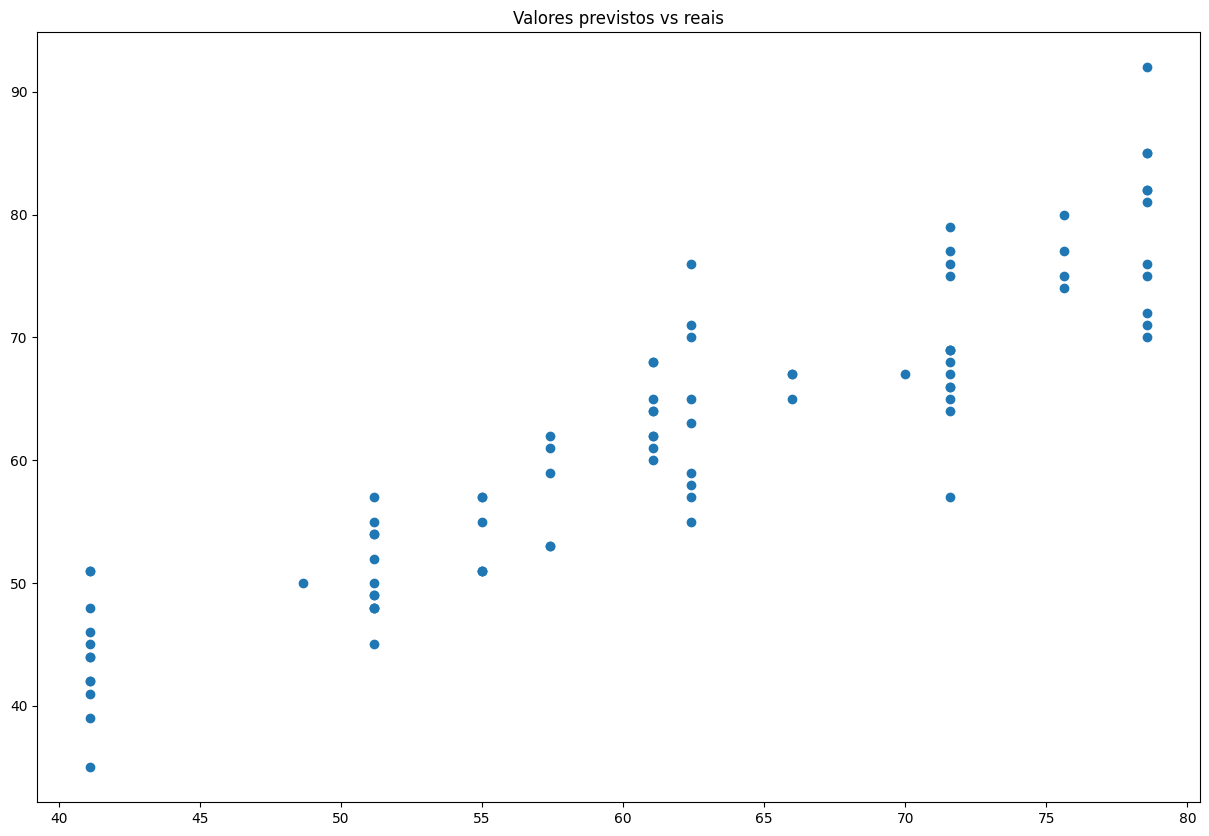

In [ ]:
fig = plt.figure(figsize=(15,10))
plt.scatter(y_pred, y_test)
plt.title('Valores previstos vs reais')
plt.show()

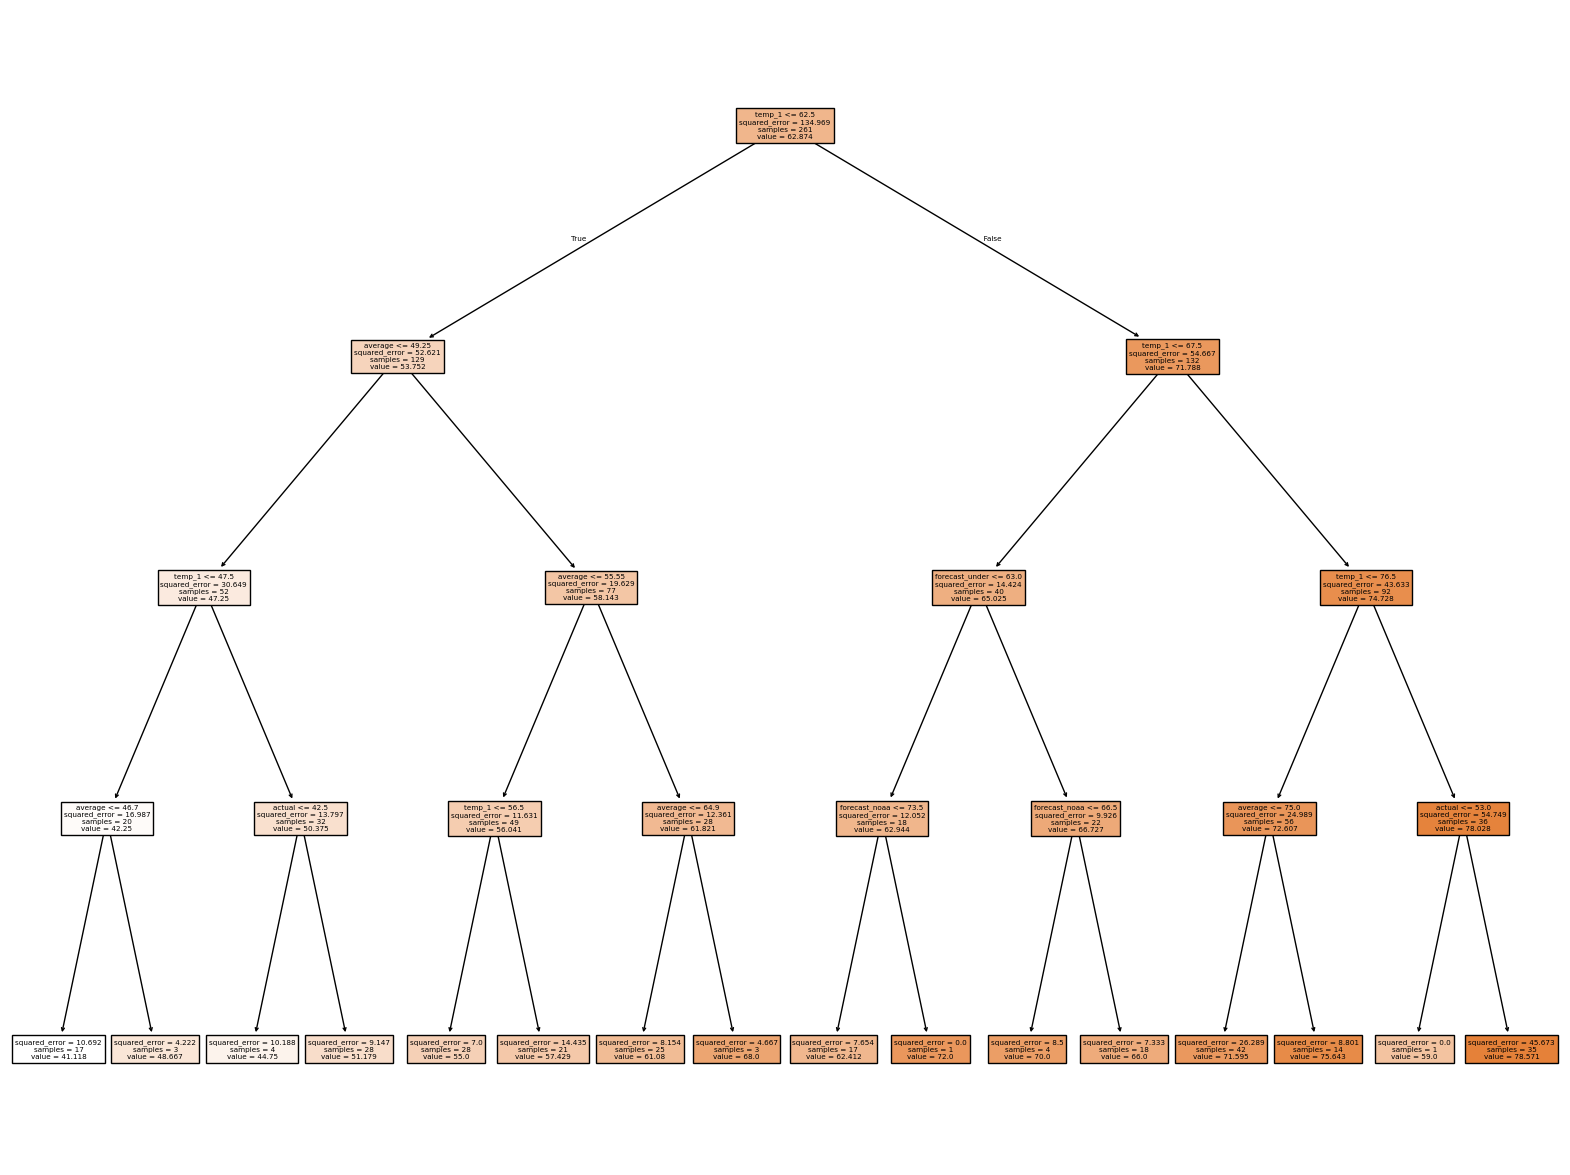

In [ ]:
fig = plt.figure(figsize=(20,15))
plt.title('Melhor regressor')
_ = tree.plot_tree(reg_best,
                   feature_names=df.columns,
                   class_names=y_test.unique(),
                   filled=True)

## **Conclusão**

Com os resultados apresentados do Regressor de Árvore de Decisão, podemos tirar algumas conclusões importantes sobre o desempenho do modelo antes e depois do ajuste de hiperparâmetros (max_depth).

# Resultados antes do ajuste de max_depth:

MEAN (Erro Médio Absoluto): ~5.60

MAPE (Erro Percentual Médio Absoluto): ~8.95%

MSE: ~54.70

RMSE: ~7.40

R²: ~0.63 → O modelo explica 63% da variabilidade dos dados de teste.

Validação cruzada: 75% de acurácia média, com desvio padrão de 6% → Resultado razoável, mas ainda há espaço para melhoria.

Esses resultados mostram um modelo com desempenho moderado, mas com possibilidade de overfitting (r² de treino provavelmente alto) ou subótimo ajuste de parâmetros.

# Após otimização com melhor max_depth:

MEAN: ~4.13 → Menor erro médio absoluto.

MAPE: ~6.79% → Melhor precisão percentual.

MSE: ~25.94 → Menor erro quadrático médio.

RMSE: ~5.09 → Menor raiz do erro quadrático.

R²: ~0.83 → Agora o modelo explica 83% da variabilidade dos dados.

Além disso, os ramos da árvore diminuíram, indicando uma árvore menos complexa e mais generalizável.

# Ajustar o max_depth melhorou significativamente o modelo:

Aumentou o poder de generalização (R² ↑)

Reduziu o erro em todas as métricas (MAE, MAPE, MSE, RMSE ↓)

A árvore ficou mais simples (menos ramos), o que reduz o risco de overfitting